# TF-IDF + Logistic Regression baseline (E0)

## Course connection

This classical baseline gives the Deep Learning methods a meaningful reference point. It also follows the course habit of comparing a simple method before interpreting a more complex model.

## Step 1 — Reuse the project split

**What this does:** loads the same train, validation, and test partitions as the neural experiments.

**Why:** a baseline is only useful when it is evaluated on exactly the same data.


In [1]:
# Reuse the central loader instead of creating a second, inconsistent split.
# Load the same split used by every later experiment.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.data.load_data import load_banking77
dataset = load_banking77(validation_size=0.1, seed=42)

## Step 2 — Train the lexical baseline

**What this does:** converts queries into TF-IDF unigrams/bigrams and trains Logistic Regression.

**Why:** this simple model shows how much intent information can be captured by words and short phrases before using Deep Learning.


In [2]:
# TF-IDF represents word and phrase importance; Logistic Regression maps those features to 77 intents.
# We record both quality metrics and training time for the later comparison.
# TF-IDF captures useful words and short phrases; Logistic Regression provides a transparent baseline.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from src.evaluation.evaluate import classification_metrics
import time
train, test = dataset["train"], dataset["test"]
model = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("classifier", LogisticRegression(max_iter=1000))])
start = time.perf_counter(); model.fit(train["text"], train["label"]); training_seconds = time.perf_counter() - start
pred = model.predict(test["text"]); metrics = classification_metrics(test["label"], pred); metrics["training_seconds"] = training_seconds; metrics

{'accuracy': 0.8561688311688311,
 'macro_precision': 0.8669232472180748,
 'macro_recall': 0.8561688311688311,
 'macro_f1': 0.8557944607611152,
 'weighted_f1': 0.8557944607611154,
 'training_seconds': 7.518891851002991}

## Step 3 — Visualize the baseline result

**What this does:** plots the baseline’s measured accuracy, precision, recall, and F1 scores.

**Why:** keeping the baseline result visible makes the later neural-model comparison easier to understand.

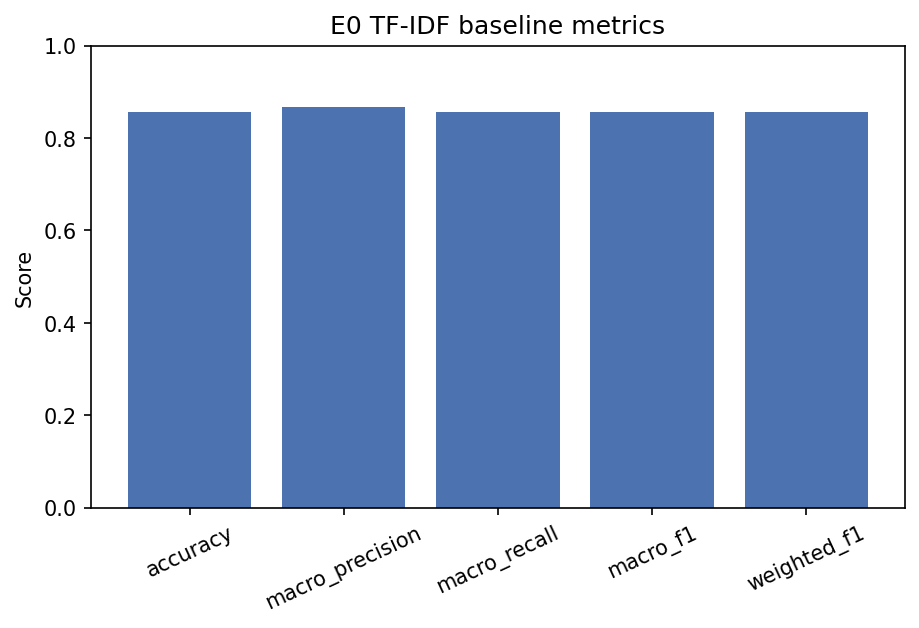

In [ ]:
# Read the saved test result rather than typing a metric by hand.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent
metrics = pd.read_csv(root / "results/metrics.csv")
baseline = metrics.loc[metrics["experiment"] == "E0_tfidf"].iloc[0]
score_names = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]
plt.figure(figsize=(7, 4))
plt.bar(score_names, [baseline[name] for name in score_names], color="#4C72B0")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("E0 TF-IDF baseline metrics")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()